<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 120px">

# Evocative of One Another: Dungeons & Dragons and Pathfinder RPG
### (Fill out this cell as the project progresses, then move to README.md as the technical report.)

*Deval Mehta*

## Table of Contents
1) [Overview](#Overview) 
2) [Data Dictionary](<#Data Dictionary>)
3) [Requirements](#Requirements)
4) [Executive Summary](#Executive-Summary)
    1) [The Data](<#The Deta>)
    2) [Baseline Values](<#Baseline Values>)
    3) [Data Transformation](<#Data Transformation>)
    4) [Model Selection Criteria](<#Model Selection Criteria>)
    5) [Analysis](#Analysis)
    6) [Implications](#Implications)
    7) [Next Steps](#Next-Steps)

## Overview
Tabletop Role Playing Games (TTRPGs) experienced a massive popularity boom in the latter half of the 2010s due to the advent of live-streaming in-person games and online gaming communities, which has continued into the present day. Two giants stand atop the high-fantasy TTRPG genre: *Dungeons & Dragons* and *Pathfinder*. The two systems are strikingly similar -- so much so that upon its inception in 2009, Pathfinder was dubbed by fans as "D&D 3.75." Among other things, the two systems share relatively similar settings, rules, and character classes. With so much in common, one might wonder from the perspective of a player or game master: are the two truly distinct enough to be considered separate systems? Our goal is to consider this question through the lens of natural language processing by analyzing posts on the subreddits r/DungeonsAndDragons and r/Pathfinder_RPG. We've retrieved nearly 2,000 posts from each subreddit using the Python Reddit API Wrapper (PRAW) to train and test our models. We generate an incredible number of features from our data by considering 1,2, and 3-grams, explore some factors that might distinguish posts on one subreddit from those of another, and finally compare the logistic regression, random forest, and support vector machine approaches to the problem.

**(Insert brief results summary here)**

## Data Dictionary
Rather than enumerating the numerous tokens of each document in our corpus, we summarize the information collected from each Reddit post.

### Collected Features
| Information | Data Type | Description | Notes |
|---|---|---|---|
| id | `string` | The individual ID number assigned to each post by Reddit | We use this to remove any possible duplicates. |
| created_utc | `float64` | The number of seconds that elapsed between 1970-Jan-01 00:00 UTC and the creation of the post. | Provided an option for de-duplicating, in case ID numbers were corrupted. |
| title | `string` | The title of each Reddit post | The most complete text data from each subreddit. |
| self_text | `string` | The body text of each Reddit post | The intended corpus. With so many missing values, we have pivoted a concatenation of `title` and `self_text`.|
| subreddit | `string` | The subreddit from which each post was retrieved | Our response variable. |

### Engineered Features
To conduct our analysis, we concatenate the `title` and `self_text` to create a new `all_text` column, which we tokenized. In addition, we created a binarized version of `subreddit` called `isDnD`, which is an integer representation of whether a post belongs to r/DungeonsAndDragons. This is done to ensure our `LogisticRegression` object will be able to interpret the two categories.

## Requirements

| Library | Module | Purpose |
|---|---|---|

**NOTE**: This project was done with Python Version 3.11.1 in Anaconda. In this iteration, the `ignore_index` argument for `pd.concat()` proves to be futile. The `Unnamed: 0` column remains persistent. As such, when concatenating, we opt to apply the `.reset_index()` method on the concatenated DataFrame with `drop = True`.

## Executive Summary
### The Data

### Baseline Values

### Data Transformation

### Model Selection Criteria

### Analysis

### Implications

### Next Steps

### Links to Sources Studied
[GeeksforGeeks' Comprehensive Guide to Classification Models in Sci-Kit Learn](https://www.geeksforgeeks.org/comprehensive-guide-to-classification-models-in-scikit-learn/)

[The RexEgg RegEx Cheat Sheet](https://www.rexegg.com/regex-quickstart.php)

[Reddit user nullus_72 provides a comprehensive answer about the differences between D&D and Pathfinder for the uninitiated](https://www.reddit.com/r/DnD/comments/11i9vjg/comment/jax4p5x/?utm_source=share&utm_medium=web3x&utm_name=web3xcss&utm_term=1&utm_content=share_button)

### Imports

In [88]:
# Staple imports for data handling, analysis, and calculation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP imports
from nltk import pos_tag
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Imports for model instantiation, fitting, and scoring
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Data tranformation and preprocessing imports
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Reddit Scraper
import praw
from reddit_scraper import *

# Warnings
from warnings import filterwarnings
filterwarnings('once')

### Load the Data in
We only need to run this cell one time. The "new" data is current as of 2024-11-24 at 7:22 PM EST. Since new data changes from minute to minute, the results here are not totally reproducible if one opts to run the following cell to recollect data.

In [2]:
# Retrieve top 1000 posts of all time from r/DungeonsAndDragons and r/Pathfinder_RPG
# unified_data('DungeonsAndDragons', 'all', 1000, 1000)
# unified_data('Pathfinder_RPG', 'all', 1000, 1000)

### Inspect and Preprocess the Data

Read in the data from the `.csv` files generated by our script `reddit_scraper.py`. The script takes the top 1000 posts of all time and the newest 1000 posts from each of our given subreddits, concatenates the listings, and removes any duplicate entries before writing out to a `.csv` file.

In [3]:
dnd = pd.read_csv('../data/DungeonsAndDragons.csv')
pathfinder = pd.read_csv('../data/Pathfinder_RPG.csv')

display(dnd.head())
display(pathfinder.head())

,id,created_utc,title,self_text,subreddit
0,7yx5bd,1.519144e+09,When you confuse Wisdom with Intelligence,NaN,DungeonsAndDragons
1,kutjp1,1.610334e+09,"Live out your fantasy this way, and you will b...",NaN,DungeonsAndDragons
2,7t9g94,1.517018e+09,Escape From Flavortown,NaN,DungeonsAndDragons
3,1guf7p9,1.731963e+09,"My patient said to me, “You must be into sport...",NaN,DungeonsAndDragons
4,7nvhag,1.514995e+09,Persuasive Bard gets persuasive...,NaN,DungeonsAndDragons


,id,created_utc,title,self_text,subreddit
0,7enkie,1.511319e+09,Love having everything you need for Pathfinder...,NaN,Pathfinder_RPG
1,10adsp3,1.673565e+09,Paizo Announces System-Neutral Open RPG License,NaN,Pathfinder_RPG
2,11b1br0,1.677271e+09,Thanks for playing Pathfinder.,We appreciate you.,Pathfinder_RPG
3,10dtypy,1.673907e+09,Newcomers; Archives of Nethys is free. It's no...,"Seriously, I've seen so many people lately com...",Pathfinder_RPG
4,10mlx2w,1.674829e+09,Pathfinder sales are through the roof followin...,NaN,Pathfinder_RPG


Assess the number of posts we have accessed. PRAW does not meet the full requested amount in a given pull. Some entries may also have been deleted, so we will not have a full 2000 posts from each subreddit.

In [4]:
dnd.shape, pathfinder.shape

((1972, 5), (1992, 5))

With 1,972 D&D posts and 1,992 Pathfinder posts, we see that our classes will be fairly balanced (nearly perfectly so). For data exploration and modeling, this means we will not have to worry about the `stratify` argument when we train-test split and we will not have to weight classes when attempting a logistic regression.

In [5]:
dnd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1972 entries, 0 to 1971
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1972 non-null   object 
 1   created_utc  1972 non-null   float64
 2   title        1972 non-null   object 
 3   self_text    658 non-null    object 
 4   subreddit    1972 non-null   object 
dtypes: float64(1), object(4)
memory usage: 77.2+ KB


In [6]:
pathfinder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1992 entries, 0 to 1991
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1992 non-null   object 
 1   created_utc  1992 non-null   float64
 2   title        1992 non-null   object 
 3   self_text    1632 non-null   object 
 4   subreddit    1992 non-null   object 
dtypes: float64(1), object(4)
memory usage: 77.9+ KB


Most of the D&D data has no body text and we lack a decent amount from the Pathfinder data as well. As such, we plan to consider the titles and body text for our analysis. Let us create a new feature which combines them.

In [7]:
# Fill N/As with empty strings so that we can concatenate
dnd.fillna('', inplace = True)
pathfinder.fillna('', inplace = True)

# Create new columns to pull features from which will serve as our corpora
dnd['all_text'] = dnd['title'] + ' ' +  dnd['self_text']
pathfinder['all_text'] = pathfinder['title'] + ' ' + pathfinder['self_text']

display(dnd.head()), display(pathfinder.head());

,id,created_utc,title,self_text,subreddit,all_text
0,7yx5bd,1.519144e+09,When you confuse Wisdom with Intelligence,,DungeonsAndDragons,When you confuse Wisdom with Intelligence
1,kutjp1,1.610334e+09,"Live out your fantasy this way, and you will b...",,DungeonsAndDragons,"Live out your fantasy this way, and you will b..."
2,7t9g94,1.517018e+09,Escape From Flavortown,,DungeonsAndDragons,Escape From Flavortown
3,1guf7p9,1.731963e+09,"My patient said to me, “You must be into sport...",,DungeonsAndDragons,"My patient said to me, “You must be into sport..."
4,7nvhag,1.514995e+09,Persuasive Bard gets persuasive...,,DungeonsAndDragons,Persuasive Bard gets persuasive...


,id,created_utc,title,self_text,subreddit,all_text
0,7enkie,1.511319e+09,Love having everything you need for Pathfinder...,,Pathfinder_RPG,Love having everything you need for Pathfinder...
1,10adsp3,1.673565e+09,Paizo Announces System-Neutral Open RPG License,,Pathfinder_RPG,Paizo Announces System-Neutral Open RPG License
2,11b1br0,1.677271e+09,Thanks for playing Pathfinder.,We appreciate you.,Pathfinder_RPG,Thanks for playing Pathfinder. We appreciate you.
3,10dtypy,1.673907e+09,Newcomers; Archives of Nethys is free. It's no...,"Seriously, I've seen so many people lately com...",Pathfinder_RPG,Newcomers; Archives of Nethys is free. It's no...
4,10mlx2w,1.674829e+09,Pathfinder sales are through the roof followin...,,Pathfinder_RPG,Pathfinder sales are through the roof followin...


Before proceeding, we should ensure that there are no null values among `all_text`

In [8]:
dnd['all_text'].isnull().sum(), pathfinder['all_text'].isnull().sum()

(0, 0)

Now we can combine our two corpora into a single corpus, which we will analyze and feed to our models. If we are successful, our new corpus will contain 3,966 documents.

In [9]:
combined_df = pd.concat([dnd, pathfinder]).reset_index(drop = True)
combined_df.shape

(3964, 6)

In [10]:
combined_df.columns

Index(['id', 'created_utc', 'title', 'self_text', 'subreddit', 'all_text'], dtype='object')

We need one more new column: a binarized version of `subreddit`. We will create a new column called `isDnD` which will be 1 if the post comes from r/DungeonsAndDragons and 0 if the post comes from r/Pathfinder_RPG. We maintain the column `subreddit`, rather than simply mapping it, so that we may use it for our Random Forest and Support Vector Machine models.

In [11]:
combined_df['isDnD'] = (combined_df['subreddit'] == 'DungeonsAndDragons').astype(int)
combined_df.head()

,id,created_utc,title,self_text,subreddit,all_text,isDnD
0,7yx5bd,1.519144e+09,When you confuse Wisdom with Intelligence,,DungeonsAndDragons,When you confuse Wisdom with Intelligence,1
1,kutjp1,1.610334e+09,"Live out your fantasy this way, and you will b...",,DungeonsAndDragons,"Live out your fantasy this way, and you will b...",1
2,7t9g94,1.517018e+09,Escape From Flavortown,,DungeonsAndDragons,Escape From Flavortown,1
3,1guf7p9,1.731963e+09,"My patient said to me, “You must be into sport...",,DungeonsAndDragons,"My patient said to me, “You must be into sport...",1
4,7nvhag,1.514995e+09,Persuasive Bard gets persuasive...,,DungeonsAndDragons,Persuasive Bard gets persuasive...,1


With the data combined, we can isolate the text and normalize it. In particular, we convert all the text in our documents to lowercase, so that, for example, "Wisdom" and "wisdom" are not counted differently. We also strip any punctuation present by invoking the `RegexpTokenizer` on all regular expression "words" (which includes unicode letters, ideograms, digits, and underscores [according to rexegg.com](https://www.rexegg.com/regex-quickstart.php). Then, we lemmatize the data by invoking `WordNetLemmatizer` before removing any stop words. This will standardize our data and prepare it for vectorization.

We preserve the id, token, subreddit, and isDnD columns for further analysis. Since sentiment analysis reads full documents, we preserve the original DataFrame separately for that purpose.

In [12]:
# Create a new DataFrame that will retain only the information we will pass into our models.
# Change the case of each word in each document to lower.
token_df = combined_df[['id', 'all_text', 'isDnD']]

In [13]:
# Instantiate RegexpTokenizer
retokenizer = RegexpTokenizer('\w+')

# Tokenize the documents in our corpus
token_df['all_text'] = [retokenizer.tokenize(doc.lower()) for doc in token_df['all_text']]

# Check that it worked
token_df.head()

<>:2: DeprecationWarning: invalid escape sequence '\w'
C:\Users\deval\AppData\Local\Temp\ipykernel_12820\10588269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  token_df['all_text'] = [retokenizer.tokenize(doc.lower()) for doc in token_df['all_text']]


,id,all_text,isDnD
0,7yx5bd,"[when, you, confuse, wisdom, with, intelligence]",1
1,kutjp1,"[live, out, your, fantasy, this, way, and, you...",1
2,7t9g94,"[escape, from, flavortown]",1
3,1guf7p9,"[my, patient, said, to, me, you, must, be, int...",1
4,7nvhag,"[persuasive, bard, gets, persuasive]",1


### Data Exploration
Now that our data has been tokenized, let's explore the data a bit. There might be some inherent differences between the posts made in each subreddit. The three criteria we consider are the length of each document in words, the tone of posts, and the most and least frequent n-grams. For the final criteria, we invoke `CountVectorizer`. During modeling, we will invoke `TfidfVectorizer` instead, to mitigate the influence of words that may be common to both subreddits.

#### Title and Post Length in Words

In [14]:
# Make a copy of the tokenized DataFrame for data analysis.
eda_df = token_df.copy()

# Create a new column called "word_count" to record the length of each document
eda_df['word_count'] = [len(doc) for doc in eda_df['all_text']]

# Check that it worked
eda_df.head()

,id,all_text,isDnD,word_count
0,7yx5bd,"[when, you, confuse, wisdom, with, intelligence]",1,6
1,kutjp1,"[live, out, your, fantasy, this, way, and, you...",1,14
2,7t9g94,"[escape, from, flavortown]",1,3
3,1guf7p9,"[my, patient, said, to, me, you, must, be, int...",1,24
4,7nvhag,"[persuasive, bard, gets, persuasive]",1,4


In [15]:
# Longest and posts, along with their subreddit.
eda_df.sort_values(by = 'word_count', ascending = False)[['all_text', 'word_count', 'isDnD']].head()

,all_text,word_count,isDnD
2643,"[tomodera, s, updated, review, of, pathfinder,...",7173,0
2197,"[tomodera, s, updated, review, of, all, pathfi...",6962,0
2670,"[tomodera, s, updated, review, of, all, pathfi...",6874,0
2717,"[errata, 2, but, it, s, just, the, new, stuff,...",5413,0
2667,"[completed, jade, regent, ap, player, impressi...",4539,0


In [16]:
# Longest and posts, along with their subreddit.
eda_df.sort_values(by = 'word_count')[['all_text', 'word_count', 'isDnD']].head()

,all_text,word_count,isDnD
35,[counterspell],1,1
657,[airdnd],1,1
100,[nope],1,1
21,[title],1,1
137,[amaarikocra],1,1


Interesting! All 5 of the longest posts come from r/Pathfinder_RPG, while all five of the shortest come from r/DungeonsAndDragons. The overall distribution

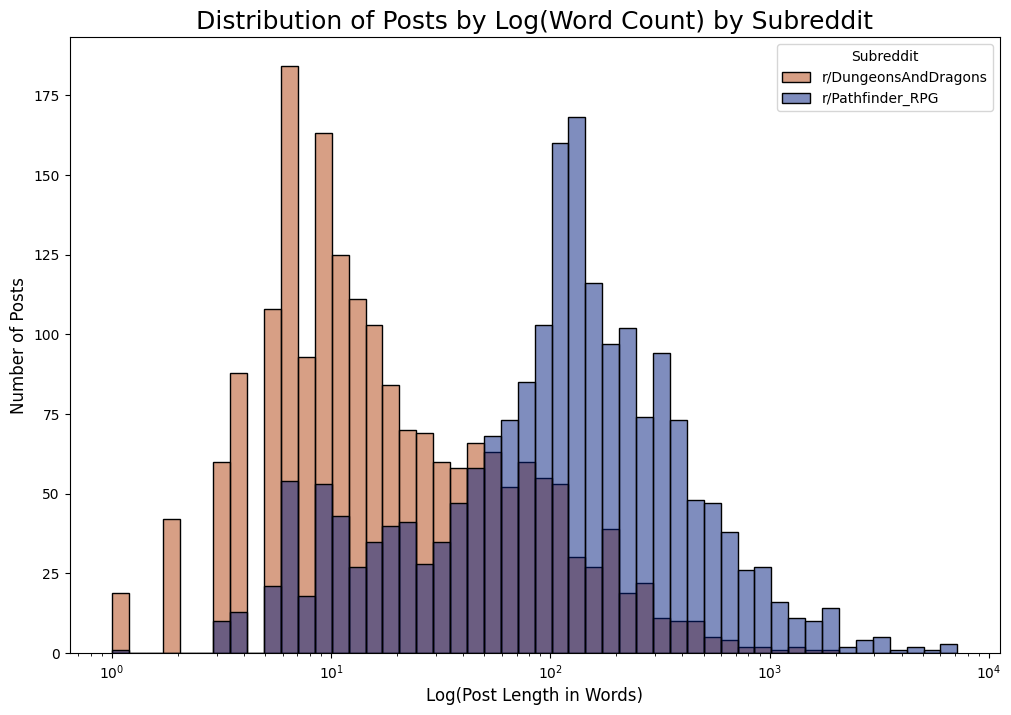

In [17]:
plt.figure(figsize = (12, 8))
sns.histplot(data = eda_df,
             x = 'word_count',
             bins = 50,
             hue = 'isDnD',
             palette = 'dark',
             log_scale = True)
plt.xlabel('Log(Post Length in Words)', fontdict = {'fontsize': 12})
plt.ylabel('Number of Posts', fontdict = {'fontsize': 12})
plt.legend(['r/DungeonsAndDragons', 'r/Pathfinder_RPG'], title = 'Subreddit')
plt.title('Distribution of Posts by Log(Word Count) by Subreddit',
          fontdict = {'fontsize': 18});

The full data confirms that this is, indeed, a general trend. Pathfinder, being a much more "rule-heavy" and specific game, tends to have longer posts than Dungeons & Dragons. This bodes well for our classifiers; there should be an appreciable difference between the posts of the two subreddits, since this also implies that the Pathfinder associated documents will have more words with possibly more limited frequency.

#### Sentiment Analysis
We consider the tone of the posts using the VADER sentiment analyzer built into NLTK. We forego the option of applying a sentiment analyzer specific to Reddit for now, but this could be a potential next step.

In [89]:
# Subset the original combined DataFrame to conduct sentiment analysis
senti_df = combined_df[['id', 'all_text', 'isDnD']]

# Instantiate VADER
analyzer = SentimentIntensityAnalyzer()

# Define a function that retrns the compound sentiment score for each document
# This is borrowed directly from the NLP Practice Breakfast Hour Content
def get_sentiment_score(doc):
    scores = analyzer.polarity_scores(doc)
    return scores['compound']

# Create a new column called "compound_sentiment" in senti_df which records the compound sentiment score of each document
senti_df['compound_sentiment'] = senti_df['all_text'].apply(lambda x: get_sentiment_score(x))

# Check that it worked
senti_df.head()

C:\Users\deval\AppData\Local\Temp\ipykernel_12820\2482309071.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  senti_df['compound_sentiment'] = senti_df['all_text'].apply(lambda x: get_sentiment_score(x))


,id,all_text,isDnD,compound_sentiment
0,7yx5bd,When you confuse Wisdom with Intelligence,1,0.6808
1,kutjp1,"Live out your fantasy this way, and you will b...",1,-0.2975
2,7t9g94,Escape From Flavortown,1,0.1779
3,1guf7p9,"My patient said to me, “You must be into sport...",1,0.3595
4,7nvhag,Persuasive Bard gets persuasive...,1,0.0000


We can compare the sentiment score distribution by subreddit, just as we did for the word count.

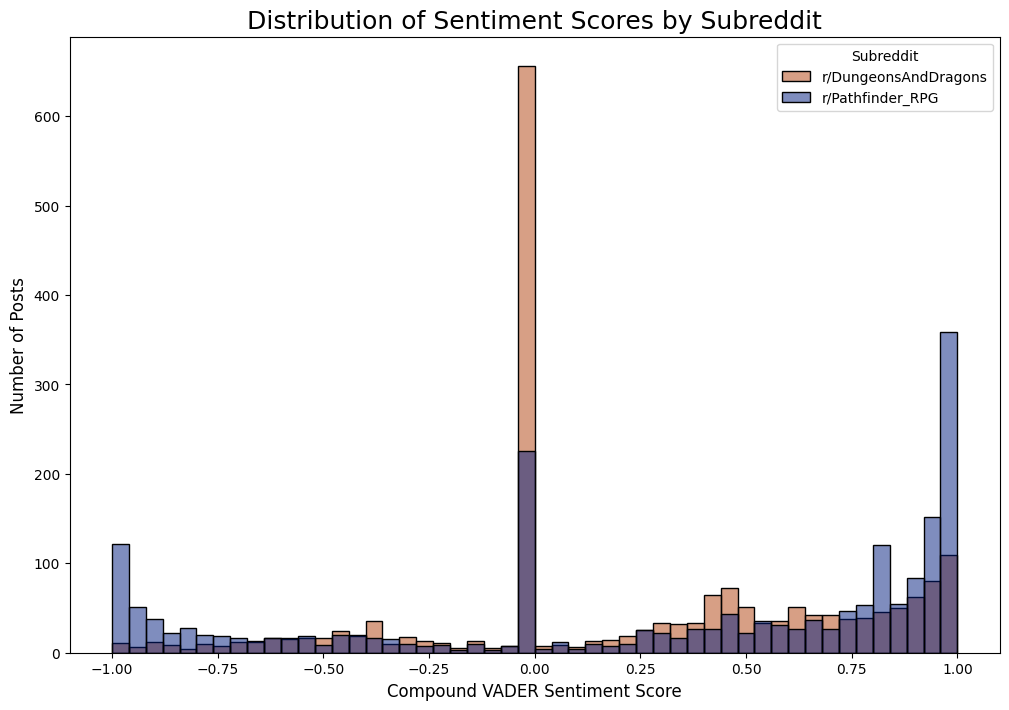

In [93]:
plt.figure(figsize = (12, 8))
sns.histplot(data = senti_df,
             x = 'compound_sentiment',
             bins = 50,
             hue = 'isDnD',
             palette = 'dark')
plt.xlabel('Compound VADER Sentiment Score', fontdict = {'fontsize': 12})
plt.ylabel('Number of Posts', fontdict = {'fontsize': 12})
plt.legend(['r/DungeonsAndDragons', 'r/Pathfinder_RPG'], title = 'Subreddit')
plt.title('Distribution of Sentiment Scores by Subreddit',
          fontdict = {'fontsize': 18});

Evidently, Pathfinder posts are far more polarized than Dungeons & Dragons posts, according to NLTK's implementation of VADER. Again, this bodes well for our classifiers.

#### Most and Least Frequent n-grams
To consider the most and least frequent words and pairs of words, we employ `CountVectorizer`. This will remove the stop words for us, as well as assign a vector to each word in the corpus. Before we can feed it a list of stop words, we must generate a custom list of stopwords from `nltk.corpus.stopwords`. We assume that both subreddits are predominantly English here, but we could amend the list of stop words to include stop words from other languages as well.

In [70]:
# Define a list of stopwords to be nltk.corpus.stopwords.words('english')
stop_words = stopwords.words('english')

# Remove all the links from the data (Thanks Angelo!)
combined_df['all_text'] = combined_df['all_text'].str.replace(r'http\S+', '', regex=True).str.strip()

# Instantiate CountVectorizer
countvec = CountVectorizer(stop_words = stop_words,
                           min_df = 0.01,
                           ngram_range = (1, 3))

# Fit and transform the CountVectorizer object to the reddit corpus
cvec_posts = countvec.fit_transform(combined_df['all_text'])

# Identify the features
features = countvec.get_feature_names_out()

# Save to a dataframe
vector_df = pd.DataFrame(
    cvec_posts.toarray(),
    columns = features
)

vector_df['sub'] = combined_df['subreddit']
# Check that it worked
vector_df.head()

,10,100,11,12,13,14,15,16,17,18,...,writing,written,wrong,x200b,yeah,year,years,yes,yet,sub
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons


Let us consider now the most frequent n-grams by subreddit. It could be the vernacular of each is appreciably different.

In [71]:
# Split vector_df by subreddit
dnd_vec = vector_df[vector_df['sub'] == 'DungeonsAndDragons']
dnd_vec.head()

,10,100,11,12,13,14,15,16,17,18,...,writing,written,wrong,x200b,yeah,year,years,yes,yet,sub
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,DungeonsAndDragons


In [72]:
pathfinder_vec = vector_df[vector_df['sub'] == 'Pathfinder_RPG']

In [73]:
dnd_freqs = dnd_vec.sum(numeric_only = True).sort_values(ascending = False).head(20)
dnd_freqs.head()

one          376
like         337
character    333
would        312
dm           296
dtype: int64

In [74]:
pathfinder_freqs = pathfinder_vec.sum(numeric_only = True).sort_values(ascending = False).head(20)

In [75]:
ngram_freqs = pd.DataFrame([dnd_freqs, pathfinder_freqs]).T.reset_index()
ngram_freqs.rename(columns = {'index': 'ngram', 0: 'dnd_freqs', 1: 'pathfinder_freqs'}, inplace = True)
ngram_freqs.head()

,ngram,dnd_freqs,pathfinder_freqs
0,one,376.0,1668.0
1,like,337.0,1453.0
2,character,333.0,905.0
3,would,312.0,1384.0
4,dm,296.0,NaN


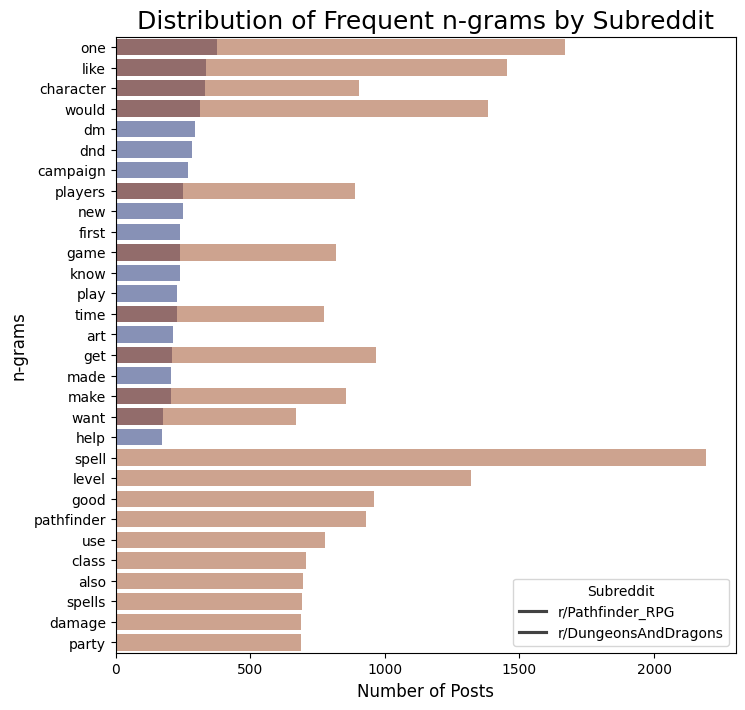

In [86]:
plt.figure(figsize = (8,8))
sns.set_palette('dark')
sns.barplot(data = ngram_freqs,
            y = 'ngram',
            x = 'dnd_freqs',
            alpha = 0.5,
            orient = 'h')
sns.barplot(data = ngram_freqs,
            y = 'ngram',
            x = 'pathfinder_freqs',
            alpha = 0.5,
            orient = 'h')
plt.ylabel('n-grams', fontdict = {'fontsize': 12})
plt.xlabel('Number of Posts', fontdict = {'fontsize': 12})
plt.legend(labels = ['r/Pathfinder_RPG', 'r/DungeonsAndDragons'], title = 'Subreddit')
plt.title('Distribution of Frequent n-grams by Subreddit',
          fontdict = {'fontsize': 18});

All of the top 20 (1,3)-grams from each subreddit are 1-grams (words). Of these, 10 appear in both subreddits frequently. Given that r/DungeonsAndDragons is less verbose than r/Pathfinder, it makes sense that the words which appear most frequently in in r/DungeonsAndDragons do so far less often than the most frequent words in r/Pathfinder. Regardless, the fact that one-third of the most popular words are shared justifies our decision to employ TFIDF Vectorization when modeling.

### Transform the Data
We have now established that there are certainly characteristics that distinguish r/DungeonsAndDragons posts from r/Pathfinder posts. With the information we have gained from our exploration of the data, we begin modeling. Before fitting any models to the data, there are a couple of steps we must take.

1) Train-Test split. We also select a random seed of 20241126 (the due date of the project) to ensure reproducability
2) Write a general transformer that will convert our data to an amenable form for classification algorithms
3) Establish any assumptions we need

In [95]:
# Train-test split
X = senti_df[['all_text', 'compound_sentiment']]
y = senti_df['isDnD']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 20241126)

#### Set up a general transformer for the data
To transform our data effectively for modeling, we must take a few steps:

1. Create a lemmatizer to transform each token
2. TFIDF Vectorize the documents with the same stop words we used in our EDA
3. Scale the data by invoking `StandardScaler`(this will only affect some of our classifiers, but we will standarize the process by writing a single transformer which we can feed to all of our models)

We employ some help from ChatGPT to complete this step, as applying `StandardScaler` after `TFIDFVectorizer` can be tricky.

In [96]:
# Define a custom lemmatizer using WordNetLemmatizer()
# These two functions are taken directly from the NLP Practice Breakfast Hour content
def custom_lemmatize(word, tag):
    lemmatizer = WordNetLemmatizer()
    pos_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    pos = pos_map.get(tag[0])
    return lemmatizer.lemmatize(word, pos) if pos else word

# Define a function that lemmatizes each token by applying the custom lemmatizer
def lemmatize(text):
    tokens = text.split(' ')
    lemmatized_tokens = [custom_lemmatize(word, tag) for word, tag in pos_tag(tokens)]
    return ' '.join(lemmatized_tokens)

In [ ]:
# Create a general transformer using ColumnTransformer to facilitate fitting the models
# First write a pipeline to handle the data coming in as full documents
# StandardScaler() requires a dense array, so we use FunctionTransformer to accomplish that
text_preprocessor = Pipeline([
    ('tfidf', TfidfVector~izer(stop_words = stop_words,
                                     preprocessor = lemmatize,
                                     min_df = 0.01), 'all_text'),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse = True))
])

# Run the text processing pipeline through ColumnTransformer to scale all the data
preprocessor = ColumnTransformer([
    ('text', text_preprocessor, 0),
    ('sc', StandardScaler(), [:])
])

### Baseline Model: Logistic Classification

### K-Nearest Neighbors Classification

### Random Forest Classification

### Support Vector Classification

### Model Analysis and Comparison

In [ ]:
# Model Evaluation
# Hyperparamater Search Visualization
# ROC Curve/AUC

### Tweak and Repeat